# COLAB 1: Building Your First Research Workflow

## Course architecture

Data acquisition ➡️ Data analysis ➡️ Visualizing results ➡️ Documenting research

**Platform Context:** Google Colab Cloud VM (Standard CPU Runtime)  
**Motivating Domain:** Brain-Machine Interfaces & Neural Signal Analysis  
**Target Open Dataset:** Neural Voltage Signals (Extracellular Spiking Arrays)

## Instructions for the student
In this lab, you will act as a Workflow Designer building an integrated, automated research workflow for a single experimental subject.

Your objective is to pass the explicit **"AI Prompt Challenges"** directly to an AI coding assistant, evaluate the structural properties of the returned functions, and paste them into the designated code boundaries. Once your 4 stages are connected, you will use the Stage 5 Laboratory Playground at the bottom of the notebook to test your workflow under different analysis settings!

## Module 1: Data acquisition

As an example, we will work with a [dataset](https://www.kaggle.com/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games?resource=download) that contains EEG signals recorded from participants playing emotionally different computer games (boring, calm, horror, funny). We will download and analyze data from participant S01.

#### Student AI prompt challenge

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Write a function get_data(data_config) that takes the DATA_CONFIG below, reads each file with pandas using urls from the values, adds a game identifier to each file (the corresponding key), concatenates all dataframe into one and returns it."

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CONFIG = {
    "boring": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G1AllChannels.csv",
    "calm": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G2AllChannels.csv",
    "horror": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G3AllChannels.csv",
    "funny": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G4AllChannels.csv"
}

In [2]:
# TODO: Your code here
def get_data(data_config):
    dataframes = []

    for game, url in data_config.items():
        df = pd.read_csv(url)
        df["game"] = game
        dataframes.append(df)

    return pd.concat(dataframes, ignore_index=True)


data = get_data(DATA_CONFIG)


In [3]:
data = get_data(DATA_CONFIG)
data.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8,Unnamed: 14,game
0,-33.0205,-15.1846,-42.1795,1.6872,42.1793,-1.68720,-5.5436,-3.6154,25.7899,-9.88190,5.5436,7.47180,11.8101,17.1128,NaN,boring
1,-28.6291,-20.0583,-42.5410,-10.4653,35.3100,-15.68600,-19.3110,-2.4344,17.4933,3.24420,18.7081,5.09510,17.3683,3.0708,NaN,boring
2,-21.8497,-10.9006,-32.0346,-2.3656,39.6993,-0.64483,-4.0523,-1.0830,26.8081,-3.45840,8.1861,8.40480,15.1209,9.3940,NaN,boring
3,-25.1185,-10.9702,-32.7641,-3.4287,32.7378,4.69650,-8.6299,-1.7412,16.7637,-9.75860,1.1868,0.91086,4.3315,8.1073,NaN,boring
4,-19.0316,-9.5886,-29.1108,-3.9459,35.3533,0.79929,-12.6914,1.0144,13.1068,-0.73692,8.1054,-1.31300,8.1694,8.3442,NaN,boring


## Module 2: Data analysis

#### Student AI prompt challenge

Copy and paste the following text block into your AI assistant:

> "Assume the columns of my dataframe are recordings from individual electrodes (AF3 to T8), with the identifier saved in the "game" column. Write a function run_anova(data) that takes each electrode in the data separately (AF3 to T8) and runs a simple ANOVA between the games. Print out the composite significance results table."

In [4]:
# TODO: Your code here
from scipy.stats import f_oneway

def run_anova(data):
    electrodes = [
        "AF3", "F7", "F3", "FC5", "T7",
        "P7", "O1", "O2", "P8", "T8",
        "FC6", "F4", "F8", "AF4"
    ]

    results = []

    for electrode in electrodes:
        groups = [
            data.loc[data["game"] == game, electrode].dropna()
            for game in ["boring", "calm", "horror", "funny"]
        ]

        # Run one-way ANOVA
        f_stat, p_value = f_oneway(*groups)

        results.append({
            "electrode": electrode,
            "F-statistic": f_stat,
            "p-value": p_value
        })

    results_df = pd.DataFrame(results)

    print(results_df)

    return results_df


In [ ]:
anova_result = run_anova(data)


ANOVA Results Across Games
  electrode   F_stat  p_value
        AF3 0.001111 0.999949
        AF4 0.012042 0.998194
         F3 0.040109 0.989291
         F4 0.008768 0.998874
         F7 0.006097 0.999346
         F8 0.081791 0.969952
        FC5 0.011744 0.998260
        FC6 0.041308 0.988820
         O1 0.012095 0.998181
         O2 0.055138 0.982970
         P7 0.077225 0.972321
         P8 0.017965 0.996726
         T7 0.037164 0.990423
         T8 0.002724 0.999804
Unnamed: 14      NaN      NaN


/var/folders/gs/_z8_31zd6xz_w20ny978y50w0000gn/T/ipykernel_1896/3816848617.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*groups)


## Module 3: Visualizing results

#### Student AI prompt challenge

Copy and paste the following text block into your AI assistant:

> "Now write a function plot_results() that takes a dataframe in this format and makes a seabron histogram showing averages and SEMs. It should also take the anova_result table from the previous step and indicate significance with stars and no significance with NS."

In [5]:
# TODO: Your code here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_results(data, anova_result):
    electrodes = [
        "AF3", "F7", "F3", "FC5", "T7",
        "P7", "O1", "O2", "P8", "T8",
        "FC6", "F4", "F8", "AF4"
    ]

    games = ["boring", "calm", "horror", "funny"]

    # Convert dataframe from wide to long format
    plot_data = data.melt(
        id_vars="game",
        value_vars=electrodes,
        var_name="electrode",
        value_name="value"
    )

    # Calculate means and SEMs
    summary = (
        plot_data
        .groupby(["electrode", "game"])["value"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    # Create plot
    plt.figure(figsize=(16, 7))

    ax = sns.barplot(
        data=summary,
        x="electrode",
        y="mean",
        hue="game",
        order=electrodes,
        hue_order=games,
        errorbar=None
    )

    # Add SEM error bars manually
    n_games = len(games)
    bar_width = 0.8 / n_games

    for i, electrode in enumerate(electrodes):
        for j, game in enumerate(games):
            row = summary[
                (summary["electrode"] == electrode) &
                (summary["game"] == game)
            ]

            if len(row) == 0:
                continue

            mean = row["mean"].iloc[0]
            sem = row["sem"].iloc[0]

            x = i - 0.4 + bar_width / 2 + j * bar_width

            ax.errorbar(
                x=x,
                y=mean,
                yerr=sem,
                fmt="none",
                color="black",
                capsize=3,
                linewidth=1
            )

    # Add significance labels from ANOVA results
    for i, electrode in enumerate(electrodes):
        result = anova_result[
            anova_result["electrode"] == electrode
        ]

        if len(result) == 0:
            continue

        p = result["p-value"].iloc[0]

        # Significance convention
        if p < 0.001:
            label = "***"
        elif p < 0.01:
            label = "**"
        elif p < 0.05:
            label = "*"
        else:
            label = "NS"

        # Find maximum bar + SEM for this electrode
        electrode_data = summary[
            summary["electrode"] == electrode
        ]

        y_max = (electrode_data["mean"] + electrode_data["sem"]).max()

        # Offset above error bars
        y_offset = 0.05 * (
            summary["mean"].max() - summary["mean"].min()
        )

        ax.text(
            i,
            y_max + y_offset,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_xlabel("Electrode")
    ax.set_ylabel("Mean signal")
    ax.set_title("Electrode Response by Game")

    plt.legend(title="Game")
    plt.tight_layout()
    plt.show()


           game    electrode    value
0        boring          AF3 -33.0205
1        boring          AF3 -28.6291
2        boring          AF3 -21.8497
3        boring          AF3 -25.1185
4        boring          AF3 -19.0316
...         ...          ...      ...
2295115   funny  Unnamed: 14      NaN
2295116   funny  Unnamed: 14      NaN
2295117   funny  Unnamed: 14      NaN
2295118   funny  Unnamed: 14      NaN
2295119   funny  Unnamed: 14      NaN

[2295120 rows x 3 columns]


/var/folders/gs/_z8_31zd6xz_w20ny978y50w0000gn/T/ipykernel_1896/2742622243.py:20: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


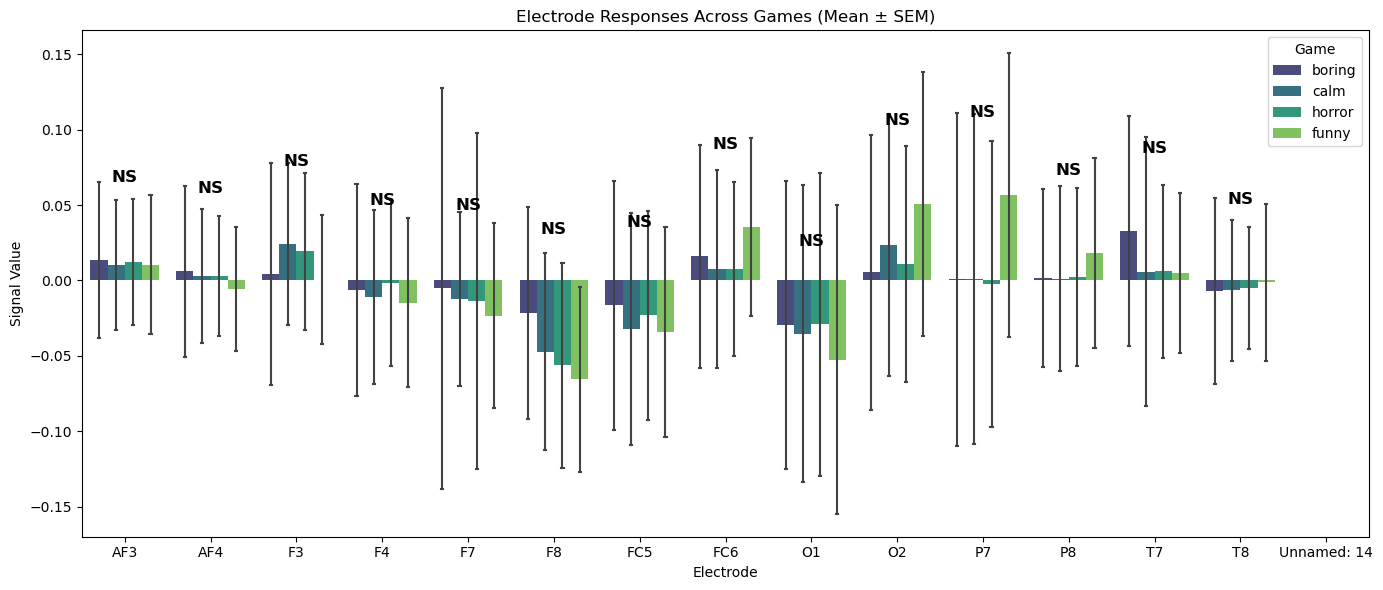

In [ ]:
plot_results(data, anova_result)

## Module 4: Documenting research

#### Student AI prompt challenge

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Assume the anova table from above is saved in the anova_result variable. Write a documentation logging function document_reserach that creates a pandas dataframe with the following columns: current date, number of singificant (p < 0.05) electrodes and returns it."

In [ ]:
# TODO: Your code here

In [ ]:
document_research(anova_result)

,date,num_significant_electrodes
0,2026-07-17,0


## Embedded playground

**Task 1.** Hypothesize which two game types could produce vastly different emotional responses and re-run the analyses only for these game types.

**Task 2.** Use AI to add basic preprocessing (re-referencing, filtering) to the workflow after obtaining the data and before running ANOVA. Does it affect the significance results?

/var/folders/gs/_z8_31zd6xz_w20ny978y50w0000gn/T/ipykernel_1896/3816848617.py:17: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*groups)



ANOVA Results Across Games
  electrode   F_stat  p_value
        AF3 0.001111 0.999949
        AF4 0.012042 0.998194
         F3 0.040109 0.989291
         F4 0.008768 0.998874
         F7 0.006097 0.999346
         F8 0.081791 0.969952
        FC5 0.011744 0.998260
        FC6 0.041308 0.988820
         O1 0.012095 0.998181
         O2 0.055138 0.982970
         P7 0.077225 0.972321
         P8 0.017965 0.996726
         T7 0.037164 0.990423
         T8 0.002724 0.999804
Unnamed: 14      NaN      NaN
           game    electrode    value
0        boring          AF3 -33.0205
1        boring          AF3 -28.6291
2        boring          AF3 -21.8497
3        boring          AF3 -25.1185
4        boring          AF3 -19.0316
...         ...          ...      ...
2295115   funny  Unnamed: 14      NaN
2295116   funny  Unnamed: 14      NaN
2295117   funny  Unnamed: 14      NaN
2295118   funny  Unnamed: 14      NaN
2295119   funny  Unnamed: 14      NaN

[2295120 rows x 3 columns]


/var/folders/gs/_z8_31zd6xz_w20ny978y50w0000gn/T/ipykernel_1896/2742622243.py:20: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


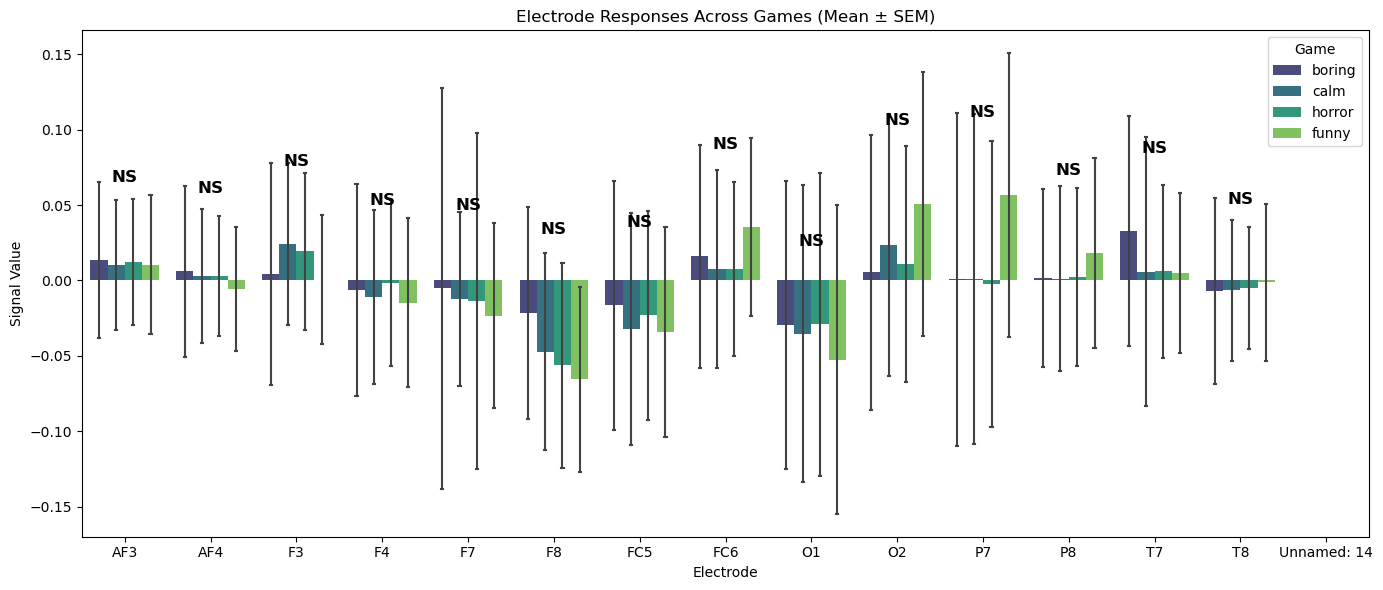

,date,num_significant_electrodes
0,2026-07-17,0


In [ ]:
data = get_data(DATA_CONFIG)
anova_result = run_anova(data)
plot_results(data, anova_result)
document_research(anova_result)